# Explore the restitution map

This notebook interactively explores the coefficient of restitution $e$ in the
$({\rm St}, n)$ parameter space.

The coefficient is computed from each simulation as

$$
e = \left|\frac{V_\infty}{V_0}\right|,
$$

where $V_0$ is the indenter initial velocity and $V_\infty$ is the velocity at the end of the simulation. The main view is a rotatable 3D column
plot; the flat panel below reproduces the 2D map from the paper figure.

Note: if using the sample data in the repo the grid is not fully populated. Point the
notebook to the full dataset (`GPU_EHL_DATA`) to see the complete map. The full dataset will be made available on Zenodo (see Data Availability section in the paper).

Joaquin Garcia-Suarez (joquin.garciasuarez@epfl.ch), 2026.


In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

# Make the shared figure style importable
sys.path.insert(0, str(repo_root / "paper" / "figures" / "scripts"))
import style as fig_style

# Resolve dataset: env var -> sample file
h5_file = fig_style.resolve_h5_path(None)
print("Dataset:", h5_file)


Dataset: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/data/sample/parametric_sample.h5


In [2]:
def load_restitution_data(h5_file):
    """Load St, n, and restitution coefficient from the HDF5 dataset."""
    stokes_list, exp_list, restitution_list = [], [], []
    with h5py.File(h5_file, "r") as f:
        for stokes_key in f.keys():
            if not stokes_key.startswith("Stokes_"):
                continue
            stokes_val = float(stokes_key.split("_")[1])
            for shape_key in f[stokes_key].keys():
                if not shape_key.startswith("Shape_"):
                    continue
                exp_val = float(shape_key.split("_")[1])
                V = np.array(f[stokes_key][shape_key]["V"])
                e = abs(V[-1] / V[0])
                stokes_list.append(stokes_val)
                exp_list.append(exp_val)
                restitution_list.append(e)
    return (
        np.array(stokes_list),
        np.array(exp_list),
        np.array(restitution_list),
    )


stokes_arr, exp_arr, e_arr = load_restitution_data(h5_file)
df = pd.DataFrame({"St": stokes_arr, "n": exp_arr, "e": e_arr})
print(df.to_string(index=False))


     St    n        e
   10.0  2.0 0.260723
  100.0  1.0 0.247483
  100.0 10.0 0.906257
  100.0  2.0 0.835239
  100.0  3.0 0.893475
  100.0  4.0 0.904768
  100.0  5.0 0.908438
  100.0  6.0 0.908629
  100.0  7.0 0.908275
  100.0  8.0 0.907384
  100.0  9.0 0.906602
 1000.0  2.0 0.970805
10000.0  2.0 0.995043


## Interactive 3D column plot

Each column stands at $(\log_{10} {\rm St},\, n)$ and its height is the
restitution coefficient $e$. Hover over a column to see the original Stokes
number, shape exponent, and $e$.


In [3]:
def mesh3d_bars(df, x_width=0.15, y_width=0.25):
    """Build a single Plotly Mesh3d trace of vertical 3D bars."""
    x = np.log10(df["St"].values)
    y = df["n"].values
    z_top = df["e"].values

    vertices = []
    faces = []
    intensities = []
    customdata = []

    for xi, yi, zi, sti, ni in zip(x, y, z_top, df["St"], df["n"]):
        base = len(vertices)
        # 8 corners of the bar
        verts = [
            [xi - x_width, yi - y_width, 0.0],
            [xi + x_width, yi - y_width, 0.0],
            [xi + x_width, yi + y_width, 0.0],
            [xi - x_width, yi + y_width, 0.0],
            [xi - x_width, yi - y_width, zi],
            [xi + x_width, yi - y_width, zi],
            [xi + x_width, yi + y_width, zi],
            [xi - x_width, yi + y_width, zi],
        ]
        vertices.extend(verts)

        # 12 triangles for the 6 faces
        local_faces = [
            [0, 1, 2], [0, 2, 3],  # bottom
            [4, 6, 5], [4, 7, 6],  # top
            [0, 5, 1], [0, 4, 5],  # sides
            [1, 6, 2], [1, 5, 6],
            [2, 7, 3], [2, 6, 7],
            [3, 4, 0], [3, 7, 4],
        ]
        faces.extend([[base + a for a in tri] for tri in local_faces])

        intensities.extend([zi] * 8)
        customdata.extend([[sti, ni, zi]] * 8)

    return go.Mesh3d(
        x=[v[0] for v in vertices],
        y=[v[1] for v in vertices],
        z=[v[2] for v in vertices],
        i=[f[0] for f in faces],
        j=[f[1] for f in faces],
        k=[f[2] for f in faces],
        intensity=intensities,
        colorscale="Plasma",
        cmin=0.0,
        cmax=1.0,
        customdata=customdata,
        hovertemplate=(
            "St: %{customdata[0]}<br>"
            "n: %{customdata[1]}<br>"
            "e: %{customdata[2]:.4f}<extra></extra>"
        ),
        name="e",
        showscale=True,
        colorbar=dict(title="e"),
    )


mesh = mesh3d_bars(df)
fig3d = go.Figure(data=[mesh])
fig3d.update_layout(
    title=dict(text="Restitution coefficient e(log St, n)", x=0.5),
    width=850,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="log<sub>10</sub> St",
        yaxis_title="n",
        zaxis_title="e",
        aspectmode="manual",
        aspectratio=dict(x=2.2, y=1.0, z=1.0),
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    ),
)
fig3d.show()

## 2D restitution map

Same representation as panel (a) of the paper figure: $e$ as a function of
shape exponent $n$ and Stokes number ${\rm St}$ (log scale).


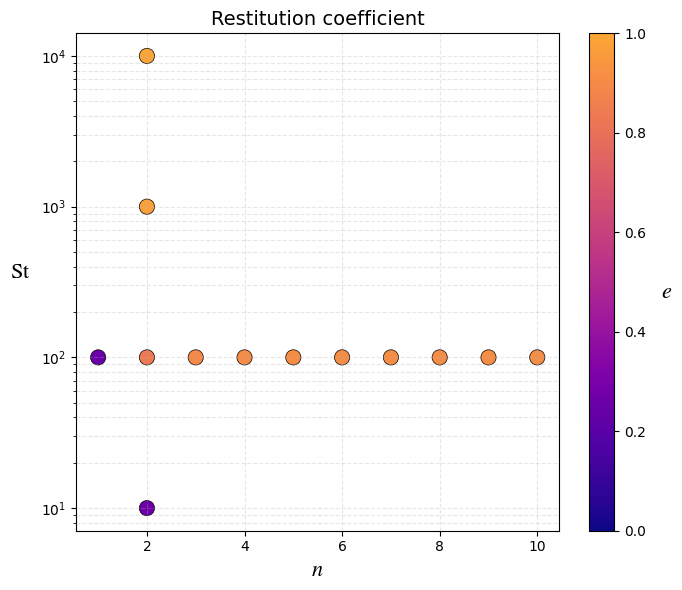

In [4]:
fig_style.setup_fonts()
plt.rcParams.update({"figure.dpi": 100})

fig2, ax = plt.subplots(figsize=(7, 6))
plasma_capped = fig_style.get_plasma_capped()
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

sc = ax.scatter(
    df["n"],
    df["St"],
    c=df["e"],
    cmap=plasma_capped,
    norm=norm,
    s=120,
    edgecolor="k",
    linewidth=0.5,
)

ax.set_yscale("log")
ax.set_xlabel(r"$n$", fontsize=16)
ax.set_ylabel(r"$\mathrm{St}$", rotation=0, labelpad=15, fontsize=16)
ax.set_title("Restitution coefficient", fontsize=14)
ax.grid(True, which="both", linestyle="--", alpha=0.3)

cbar = fig2.colorbar(sc, ax=ax)
cbar.set_label(r"$e$", rotation=0, labelpad=15, fontsize=16)

plt.tight_layout()
plt.show()

The points are colored by $e$ using the same capped plasma colormap as the paper
figure. The interactive 3D view above makes the dependence on both parameters
clearer; the 2D map gives the flat overview.
